In [1]:
# conection to google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# unziping dataset
!unzip /content/drive/MyDrive/data/Animals-10.zip -d /content/dataset

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/raw-img/ragno/OIP-MVQChNQpHiMZEVMPehrvoAHaE6.jpeg  
  inflating: /content/dataset/raw-img/ragno/OIP-MVdIFDAFpNyK_XCpwkDIWgHaFj.jpeg  
  inflating: /content/dataset/raw-img/ragno/OIP-MYY_8k5AHqMJwTCNXfH6rwHaFj.jpeg  
  inflating: /content/dataset/raw-img/ragno/OIP-MZEVXuoMsATG8u_UuTQ6hAHaE8.jpeg  
  inflating: /content/dataset/raw-img/ragno/OIP-MZg0tznDRE95AMfyuutuYAHaE6.jpeg  
  inflating: /content/dataset/raw-img/ragno/OIP-M_r9DkR2X5gP0P5-z8wPYQHaE7.jpeg  
  inflating: /content/dataset/raw-img/ragno/OIP-M_xDUSzjlF3-w9XHCm93cgHaFF.jpeg  
  inflating: /content/dataset/raw-img/ragno/OIP-MbI4-bMyutRX3X382IAVcQAAAA.jpeg  
  inflating: /content/dataset/raw-img/ragno/OIP-MbMksZdD7gomsC9fd6cpKgHaHJ.jpeg  
  inflating: /content/dataset/raw-img/ragno/OIP-Md4AMcvjaHcivJqeW06wEwHaFW.jpeg  
  inflating: /content/dataset/raw-img/ragno/OIP-MgCgailkT5XkO1XczzQCngHaLK.jpeg  
  inflating: /content/dataset/raw-img/ragno/OIP

In [3]:
# imports
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import os
from PIL import Image
from collections import Counter

import torch
from torch import optim
import torchvision
from torchvision import models
import torchvision.datasets
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision.utils import make_grid
from torchvision.io import read_image

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix

# **init MobileNetV2**

In [55]:
model = models.mobilenet_v2(pretrained=True)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth
100%|██████████| 13.6M/13.6M [00:00<00:00, 101MB/s] 


In [56]:
model

MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

# **2. Налаштування кількості вихідних класів**

# **loading data**

In [57]:
# counting number of images in classes
path = '/content/dataset/raw-img'
classes = os.listdir(path)

class_names = {}
for class_name in classes:
  class_names[class_name] = len(os.listdir(os.path.join(path, class_name)))

class_names

{'gallina': 3098,
 'scoiattolo': 1862,
 'pecora': 1820,
 'mucca': 1866,
 'gatto': 1668,
 'ragno': 4821,
 'farfalla': 2112,
 'elefante': 1446,
 'cane': 4863,
 'cavallo': 2623}

In [58]:
# loading dataset
data = torchvision.datasets.ImageFolder(root='/content/dataset/raw-img', transform=None)

In [59]:
# getting classes names
classes = data.classes
num_classes = len(classes)
print(f'data classes: {classes}, number of classes: {num_classes}')

data classes: ['cane', 'cavallo', 'elefante', 'farfalla', 'gallina', 'gatto', 'mucca', 'pecora', 'ragno', 'scoiattolo'], number of classes: 10


In [61]:
model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

In [63]:
model.classifier[1]

Linear(in_features=1280, out_features=10, bias=True)

# **3. Проведення донавчання моделі**

In [68]:
layers = [i for i in range(18, -1, -1)]
layers

[18, 17, 16, 15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0]

In [107]:
def unfreeze_layers(model, epoch, total_epochs):
    layer_indices = layers[1:]
    layers_to_unfreeze = int(epoch / total_epochs * len(layer_indices))
    for i, (name, param) in enumerate(model.named_parameters()):
        if i < layers_to_unfreeze:
            param.requires_grad = True

In [72]:
for param in model.parameters():
    param.requires_grad = False

for param in model.features[-1].parameters():
    param.requires_grad = True

In [73]:
learning_rate = 1e-4

In [74]:
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=learning_rate)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=10, threshold=0.0001, threshold_mode='abs')

In [75]:
IMAGE_SIZE = (224, 224)
MEANS = [0.517645001411438, 0.5002366304397583, 0.4124912917613983]
STDS = [0.2544998228549957, 0.2494899481534958, 0.2677474021911621]

In [76]:
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE[0]),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEANS, std=STDS)
])

In [77]:
transform_test = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEANS, std=STDS)
])

In [78]:
# transtating classes to english
translate = {"cane": "dog", "cavallo": "horse", "elefante": "elephant", "farfalla": "butterfly", "gallina": "chicken", "gatto": "cat", "mucca": "cow",
             "pecora": "sheep", "ragno": "spider", "scoiattolo": "squirrel"}
classes_eng = [translate[animal] for animal in translate]

# **dividing dataset to train and test**

In [79]:
# dividing dataset to train, validation and test
train_size = int(len(data) * 0.7)
test_size = int(len(data) * 0.15)
val_size = int(len(data) - train_size - test_size)

train_data, test_data, valid_data = random_split(dataset=data, lengths=[train_size, test_size, val_size])
print(f'train: {len(train_data):<20} test: {len(test_data):<20} validation: {len(valid_data)}')

train: 18325                test: 3926                 validation: 3928


## **adding transformation to datasets**

In [80]:
class SubsetWithTransform():
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        image, label = self.subset[index]
        if self.transform:
            image = self.transform(image)
        return image, label

    def __len__(self):
        return len(self.subset)

In [81]:
train_data = SubsetWithTransform(train_data, transform=train_transforms)
test_data = SubsetWithTransform(test_data, transform=transform_test)
valid_data = SubsetWithTransform(valid_data, transform=train_transforms)

In [82]:
train_data.transform, test_data.transform, valid_data.transform

(Compose(
     RandomResizedCrop(size=(224, 224), scale=(0.08, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
     RandomHorizontalFlip(p=0.5)
     RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
     ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=None)
     ToTensor()
     Normalize(mean=[0.517645001411438, 0.5002366304397583, 0.4124912917613983], std=[0.2544998228549957, 0.2494899481534958, 0.2677474021911621])
 ),
 Compose(
     Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
     ToTensor()
     Normalize(mean=[0.517645001411438, 0.5002366304397583, 0.4124912917613983], std=[0.2544998228549957, 0.2494899481534958, 0.2677474021911621])
 ),
 Compose(
     RandomResizedCrop(size=(224, 224), scale=(0.08, 1.0), ratio=(0.75, 1.3333), interpolation=bilinear, antialias=True)
     RandomHorizontalFlip(p=0.5)
     RandomRotation(degrees=[-15.0, 15.0], interpolation=neare

## **creating data loaders**

In [83]:
num_workers = 2

In [84]:
batch_size=32
batch_size

32

In [85]:
# creating data loader
data_loader = DataLoader(dataset=data, batch_size=batch_size, shuffle=True, num_workers=num_workers)
data_loader

In [86]:
# creating data loader for test and train data
train_loader = DataLoader(dataset=train_data, batch_size=batch_size, shuffle=True, num_workers=num_workers)
test_loader = DataLoader(dataset=test_data, batch_size=batch_size, shuffle=False, num_workers=num_workers)

In [87]:
# creating data loader for validation data
valid_loader = DataLoader(dataset=valid_data, batch_size=batch_size, shuffle=False, num_workers=num_workers)

In [88]:
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
model.to(device)

MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [89]:
loss_function = nn.CrossEntropyLoss()

In [90]:
number_epochs = 34
number_epochs

34

In [91]:
len(valid_data), valid_loader.batch_size

(3928, 32)

In [92]:
print(f'Model: {model},\n\nLoss function: {loss_function},\n\nOptimizer: {optimizer},\n\nScheduler: {scheduler}')

Model: MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(9

In [93]:
def evaluate_metrics(model, data_loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
    precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)
    recall = recall_score(all_labels, all_preds, average="macro", zero_division=0)
    f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    return accuracy * 100, precision, recall, f1

In [94]:
train_loss_list = []
val_loss_list = []
train_metrics = {metric: [] for metric in ['accuracy', 'f1_score', 'recall_score', 'precision']}
val_metrics = {metric: [] for metric in ['accuracy', 'f1_score', 'recall_score', 'precision']}

In [95]:
def train_epoch():
  model.train()
  train_loss = torch.tensor(0.0, device=device)

  for images, labels in train_loader:
      images, labels = images.to(device), labels.to(device)
      optimizer.zero_grad()
      outputs = model(images)
      loss = loss_function(outputs, labels)
      loss.backward()
      optimizer.step()
      train_loss += loss.item()

  train_loss = train_loss.item() / len(train_loader)
  train_loss_list.append(train_loss)

  train_accuracy, train_precision, train_recall, train_f1 = evaluate_metrics(model, train_loader)
  train_metrics['accuracy'].append(train_accuracy)
  train_metrics['f1_score'].append(train_f1)
  train_metrics['recall_score'].append(train_recall)
  train_metrics['precision'].append(train_precision)
  return train_loss, train_accuracy, train_precision, train_recall, train_f1

In [96]:
def eval_epoch():
  model.eval()
  val_loss = torch.tensor(0.0, device=device)

  with torch.no_grad():
      for images, labels in valid_loader:
          images, labels = images.to(device), labels.to(device)
          outputs = model(images)
          loss = loss_function(outputs, labels)
          val_loss += loss.item()

  val_loss = val_loss.item() / len(valid_loader)
  val_loss_list.append(val_loss)

  val_accuracy, val_precision, val_recall, val_f1 = evaluate_metrics(model, valid_loader)
  val_metrics['accuracy'].append(val_accuracy)
  val_metrics['f1_score'].append(val_f1)
  val_metrics['recall_score'].append(val_recall)
  val_metrics['precision'].append(val_precision)
  return val_loss, val_accuracy, val_precision, val_recall, val_f1

In [108]:
for epoch in range(number_epochs):

    unfreeze_layers(model, epoch, number_epochs)

    train_loss, train_accuracy, train_precision, train_recall, train_f1 = train_epoch()
    val_loss, val_accuracy, val_precision, val_recall, val_f1 = eval_epoch()
    scheduler.step(val_loss)

    print(f"Epoch {epoch+1}/{number_epochs}:"
          f"\n\tTrain Loss: {train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%,"
          f"\n\tTrain Precision: {train_precision:.4f}, Train Recall: {train_recall:.4f}, Train F1-score: {train_f1:.4f}"
          f"\n\tVal Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.2f}%,"
          f"\n\tVal Precision: {val_precision:.4f}, Val Recall: {val_recall:.4f}, Val F1-score: {val_f1:.4f}\n")

Epoch 1/34:
	Train Loss: 0.9559, Train Accuracy: 85.66%,
	Train Precision: 0.8509, Train Recall: 0.8438, Train F1-score: 0.8469
	Val Loss: 0.5643, Validation Accuracy: 85.31%,
	Val Precision: 0.8487, Val Recall: 0.8364, Val F1-score: 0.8420

Epoch 2/34:
	Train Loss: 0.5507, Train Accuracy: 86.76%,
	Train Precision: 0.8637, Train Recall: 0.8558, Train F1-score: 0.8594
	Val Loss: 0.4766, Validation Accuracy: 86.07%,
	Val Precision: 0.8565, Val Recall: 0.8469, Val F1-score: 0.8511

Epoch 3/34:
	Train Loss: 0.4980, Train Accuracy: 87.36%,
	Train Precision: 0.8753, Train Recall: 0.8584, Train F1-score: 0.8662
	Val Loss: 0.4399, Validation Accuracy: 86.23%,
	Val Precision: 0.8622, Val Recall: 0.8433, Val F1-score: 0.8520

Epoch 4/34:
	Train Loss: 0.4569, Train Accuracy: 87.86%,
	Train Precision: 0.8766, Train Recall: 0.8638, Train F1-score: 0.8696
	Val Loss: 0.4377, Validation Accuracy: 87.30%,
	Val Precision: 0.8710, Val Recall: 0.8571, Val F1-score: 0.8632

Epoch 5/34:
	Train Loss: 0.4411,

KeyboardInterrupt: 

Text(0.5, 1.0, 'Train Recall Score')

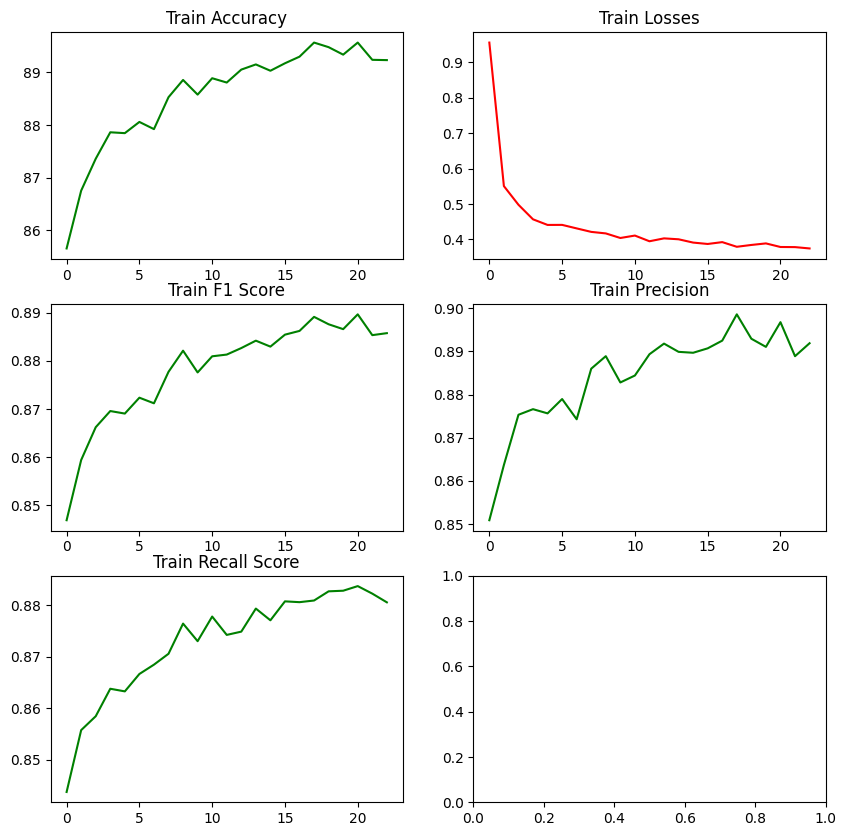

In [109]:
fig, ax = plt.subplots(3, 2, figsize=(10, 10))

ax[0,0].plot(train_metrics['accuracy'], color='g')
ax[0,0].set_title('Train Accuracy')

ax[0,1].plot(train_loss_list, color='r')
ax[0,1].set_title('Train Losses')

ax[1,0].plot(train_metrics['f1_score'], color='g')
ax[1,0].set_title('Train F1 Score')

ax[1,1].plot(train_metrics['precision'], color='g')
ax[1,1].set_title('Train Precision')

ax[2,0].plot(train_metrics['recall_score'], color='g')
ax[2,0].set_title('Train Recall Score')

Text(0.5, 1.0, 'Validation Recall Score')

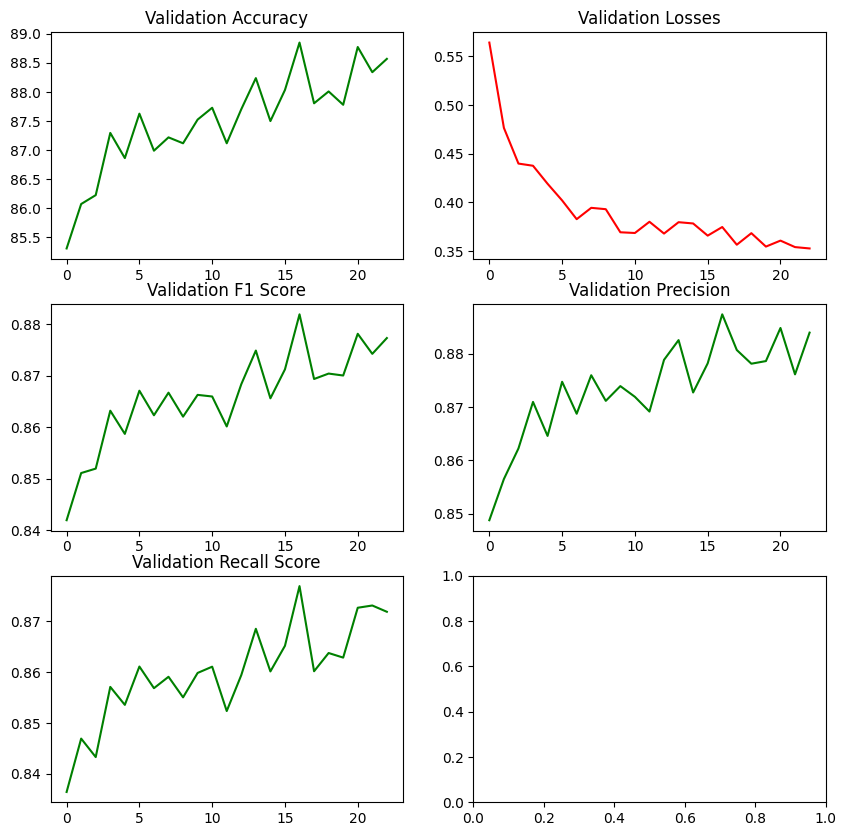

In [110]:
fig, ax = plt.subplots(3, 2, figsize=(10, 10))

ax[0,0].plot(val_metrics['accuracy'], color='g')
ax[0,0].set_title('Validation Accuracy')

ax[0,1].plot(val_loss_list, color='r')
ax[0,1].set_title('Validation Losses')

ax[1,0].plot(val_metrics['f1_score'], color='g')
ax[1,0].set_title('Validation F1 Score')

ax[1,1].plot(val_metrics['precision'], color='g')
ax[1,1].set_title('Validation Precision')

ax[2,0].plot(val_metrics['recall_score'], color='g')
ax[2,0].set_title('Validation Recall Score')

In [111]:
all_labels = []
all_preds = []
all_images = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)

        all_labels.append(labels.cpu().numpy())
        all_preds.append(predicted.cpu().numpy())
        all_images.append(images.cpu().numpy())

all_labels = np.concatenate(all_labels)
all_preds = np.concatenate(all_preds)
all_images = np.concatenate(all_images)

In [112]:
incorrect_indices = np.where(all_labels != all_preds)[0]
incorrect_images = all_images[incorrect_indices]
incorrect_labels = all_labels[incorrect_indices]
incorrect_preds = all_preds[incorrect_indices]

In [113]:
len(incorrect_indices), len(all_labels), len(incorrect_labels) / len(all_labels) * 100

(196, 3926, 4.99235863474274)

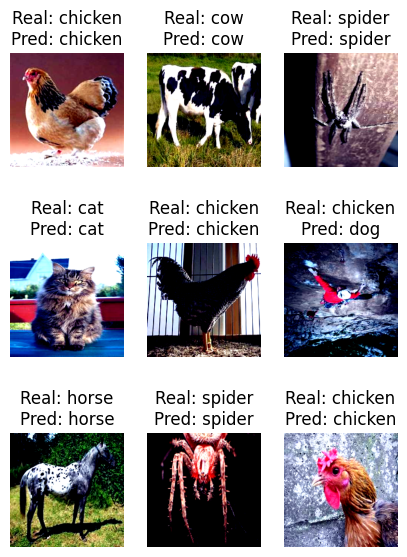

In [114]:
fig, axes = plt.subplots(3, 3, figsize=(5, 7))
model.eval()

images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)
outputs = model(images)
_, predicted = outputs.max(1)

for i, ax in enumerate(axes.flat):
    img = images[i]
    img = img / 2 + 0.5
    img = img.cpu().numpy().transpose((1, 2, 0))
    ax.imshow(img)
    ax.set_title(f'Real: {classes_eng[labels[i].item()]}\nPred: {classes_eng[predicted[i].item()]}')
    ax.axis('off')
plt.show()

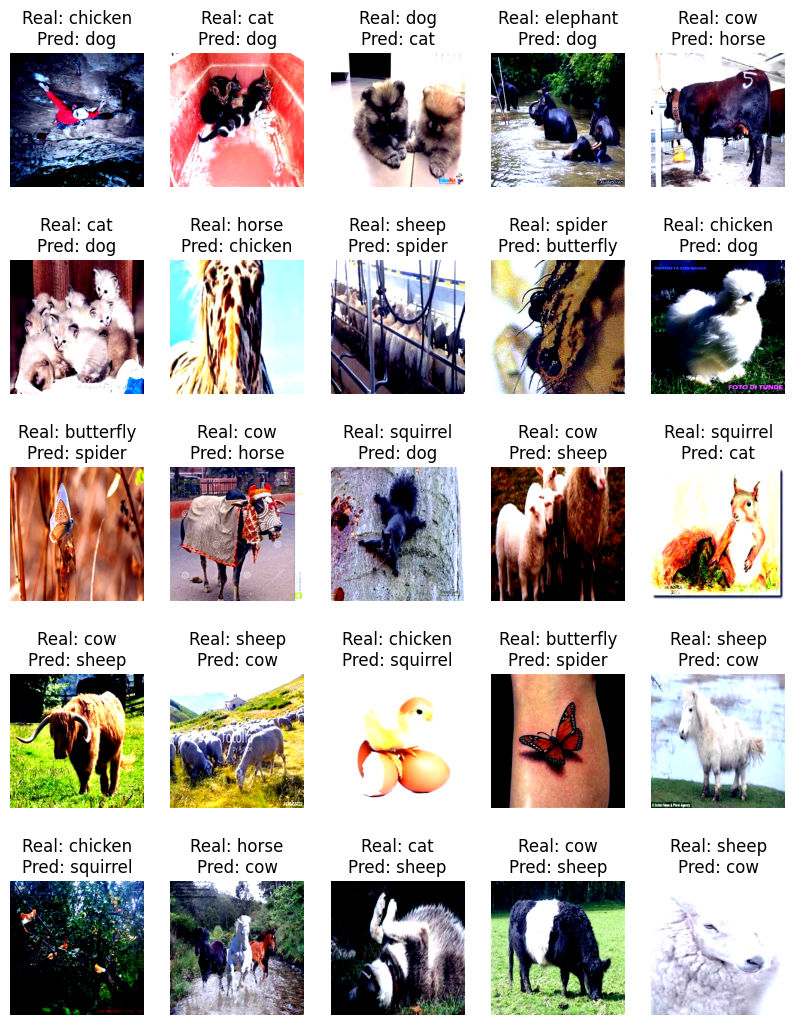

In [115]:
fig, axes = plt.subplots(5, 5, figsize=(10, 13))

for i, ax in enumerate(axes.flat):
    if i < len(incorrect_images):
        img = incorrect_images[i]
        img = img.transpose((1, 2, 0))
        img = (img * 0.5) + 0.5

        ax.imshow(img)
        ax.set_title(f'Real: {classes_eng[incorrect_labels[i]]}\nPred: {classes_eng[incorrect_preds[i]]}')
        ax.axis('off')
    else:
        ax.axis('off')

plt.show()

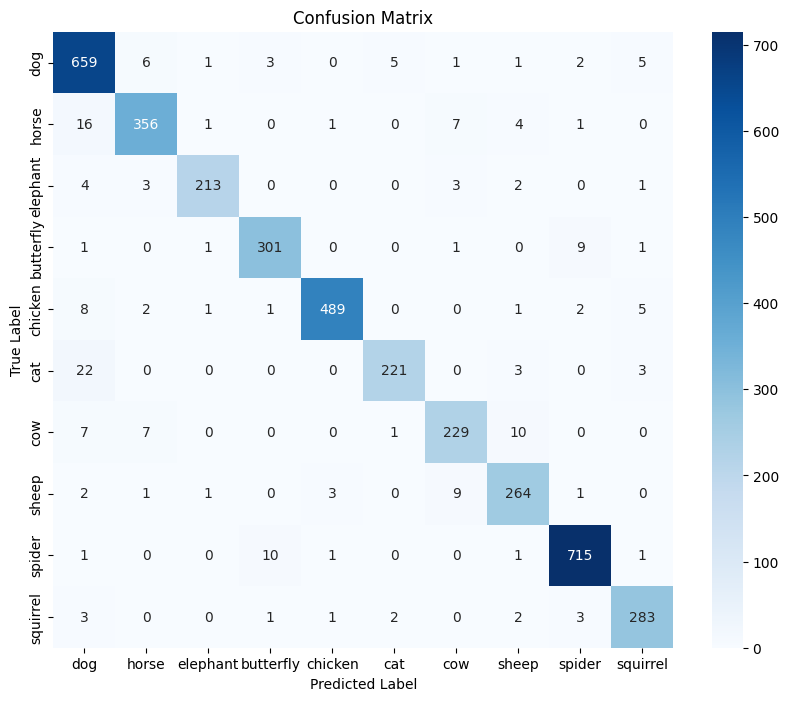

In [116]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes_eng, yticklabels=classes_eng)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

Найкраще передбачення були зроблені на класах "Павук" та "Собака", можливо це зумовлено найбільшою часткою зображень даних класів в датасеті. Отже точність передбачень може залежати від кількості екземплярів представників певного класу.

In [117]:
print(classification_report(all_labels, all_preds, target_names=classes_eng))

              precision    recall  f1-score   support

         dog       0.91      0.96      0.94       683
       horse       0.95      0.92      0.94       386
    elephant       0.98      0.94      0.96       226
   butterfly       0.95      0.96      0.96       314
     chicken       0.99      0.96      0.97       509
         cat       0.97      0.89      0.92       249
         cow       0.92      0.90      0.91       254
       sheep       0.92      0.94      0.93       281
      spider       0.98      0.98      0.98       729
    squirrel       0.95      0.96      0.95       295

    accuracy                           0.95      3926
   macro avg       0.95      0.94      0.95      3926
weighted avg       0.95      0.95      0.95      3926



Найкращі f1 score у класу 'spider' (0.98)

Найгірші - у 'cow' (0.91)

In [118]:
torch.save(model.state_dict(), 'model_best.pth')